[INFO] загрузка данных...
[INFO] Всего изображений найдено: 3000
C:/Users/betin/Desktop/Lab4_2-4_12/4_6/animals\cats\cats_00477.jpg
C:/Users/betin/Desktop/Lab4_2-4_12/4_6/animals\dogs\dogs_00547.jpg
C:/Users/betin/Desktop/Lab4_2-4_12/4_6/animals\panda\panda_00620.jpg
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
21

c:\Users\betin\Desktop\Lab4_2-4_12\env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[1] компиляция нейросети...
[2] тренировка нейросети...
Epoch 1/75
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.5104 - loss: 1.4379 - val_accuracy: 0.3147 - val_loss: 2.0660
Epoch 2/75
 1/70 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.5938 - loss: 0.8173

c:\Users\betin\Desktop\Lab4_2-4_12\env\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5938 - loss: 0.8173 - val_accuracy: 0.3147 - val_loss: 1.9249
Epoch 3/75
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.5884 - loss: 1.0577 - val_accuracy: 0.3147 - val_loss: 2.8959
Epoch 4/75
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5938 - loss: 0.9091 - val_accuracy: 0.3147 - val_loss: 3.5685
Epoch 5/75
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.6195 - loss: 0.9189 - val_accuracy: 0.3120 - val_loss: 2.6686
Epoch 6/75
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5312 - loss: 1.0032 - val_accuracy: 0.3147 - val_loss: 2.7259
Epoch 7/75
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.6271 - loss: 0.8341 - val_accuracy: 0.3147 - val_loss: 2.0328
Epoch 8/75
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6875 - loss: 0.7429 - val_accuracy: 0.3133 - val_loss: 2.1988
Epoch 9/75
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.6235 - loss: 0.8179 - val_accuracy: 0.4640 - val_loss: 1.2126

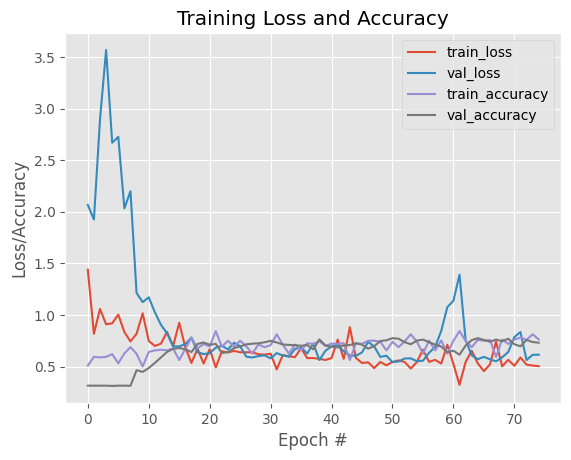

[5] сохранение модели нейросети...
[6] сохранение бинаризатора меток...


<Figure size 640x480 with 0 Axes>

In [23]:
#подключаем наш модуль
import module.net as net
#из модуля подключаем объект - класс NetModel
from module.net import NetModel
#для бинаризации меток выходного параметра Y (классы изображений)
from sklearn.preprocessing import LabelBinarizer
#для разделения датасета на тренировочный и тестовый
from sklearn.model_selection import train_test_split
#для вывода отчета по метрикам в сводном виде
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import SGD
#для работы с хранилищем
import glob
import os
#отключение предупреждений
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
#для задания пути к файлам
from imutils import paths
#для графиков
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import random
#для работы с dump
#в нашем случае, для сохранения файла бинарных меток изображений
import pickle
#для работы с изображениями
#imread, resize
import cv2

print("[INFO] загрузка данных...")
data = []
labels = []

dataset='C:/Users/betin/Desktop/Lab4_2-4_12/4_6/animals'

imagePaths = sorted(glob.glob(os.path.join(dataset, '**', '*.jpg'),  
                              recursive=True))
print(f"[INFO] Всего изображений найдено: {len(imagePaths)}")

random.seed(42)
random.shuffle(imagePaths)

print(imagePaths[100])
print(imagePaths[1020])
print(imagePaths[2999])

i=0
for imagePath in imagePaths:
    print(i)
    # загружаем изображение, меняем размер на 64x64 пикселей
    # изменённое изображение добавляем в список
    image = cv2.imread(imagePath)
    image = cv2.resize(image, (64, 64))
    data.append(image)
    # извлекаем метку класса из пути к изображению и обновляем список
    # меток (принадлежность к классу)
    label = imagePath.split(os.path.sep)[-2]
    labels.append(label)
    i=i+1

data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)

(trainX, testX, trainY, testY) = train_test_split(data, labels,
test_size=0.25, random_state=42)

print(trainX.shape)
print(trainY.shape)
print(testX.shape)
print(testY.shape)

lb = LabelBinarizer()
trainY = lb.fit_transform(trainY)
testY = lb.transform(testY)

print(len(lb.classes_))
print(lb.classes_)

autogen = ImageDataGenerator(rotation_range=30, width_shift_range=0.1,
height_shift_range=0.1, shear_range=0.2, zoom_range=0.2,
horizontal_flip=True, fill_mode="nearest")

model = NetModel.build(width=64, height=64, depth=3,
classes=len(lb.classes_))

INIT_LR = 0.01
epochs = 75
batch_size = 32

print("[1] компиляция нейросети...")
opt = SGD(learning_rate=INIT_LR, weight_decay=INIT_LR / epochs)
model.compile(loss="categorical_crossentropy", optimizer=opt,
metrics=["accuracy"])

opt = tf.keras.optimizers.SGD(learning_rate=INIT_LR, weight_decay=INIT_LR
                              / epochs)

print("[2] тренировка нейросети...")
history = model.fit(autogen.flow(trainX, trainY, batch_size=batch_size),
                    validation_data=(testX, testY),
                    steps_per_epoch=len(trainX) // batch_size,
                    epochs=epochs)

print("[3] тестирование нейросети...")
predictions = model.predict(testX, batch_size=batch_size)
print(classification_report(testY.argmax(axis=1),
predictions.argmax(axis=1), target_names=lb.classes_))

plot='C:/Users/betin/Desktop/Lab4_2-4_12/4_6/images'

print("[4] сохранение графика")
N = np.arange(0, epochs)
plt.style.use("ggplot")
plt.figure()
plt.plot(N, history.history["loss"], label="train_loss")
plt.plot(N, history.history["val_loss"], label="val_loss")
plt.plot(N, history.history["accuracy"], label="train_accuracy")
plt.plot(N, history.history["val_accuracy"], label="val_accuracy")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()
# сохраняем график
plt.savefig(plot)

model_file='C:/Users/betin/Desktop/Lab4_2-4_12/4_6/animals/output/model.keras'
label_bin='C:/Users/betin/Desktop/Lab4_2-4_12/4_6/animals/output/net_lb.pickle'

print("[5] сохранение модели нейросети...")
model.save(model_file)
print("[6] сохранение бинаризатора меток...")
f = open(label_bin, "wb")
f.write(pickle.dumps(lb))
f.close()

